In [1]:
import pandas as pd
import numpy as np
import xarray as xr

In [4]:
dat = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_clean.csv")

In [5]:
dat['DATE'] =  pd.to_datetime(dat['DATE'], errors="coerce")

In [6]:
dat = dat.dropna(subset=['DATE'])

In [7]:
dat['PRCP'] = pd.to_numeric(dat['PRCP'], errors="coerce")

In [8]:
dat = dat.set_index('DATE').sort_index()

In [9]:
datm = dat['PRCP'].resample('M').sum()

/tmp/ipykernel_3260/3961926218.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datm = dat['PRCP'].resample('M').sum()


In [16]:
datm.index = datm.index.to_period("M").to_timestamp()

In [10]:
datm

DATE
1877-07-31      0.0
1877-08-31      0.0
1877-09-30      0.0
1877-10-31     18.6
1877-11-30     27.2
              ...  
2025-02-28    109.7
2025-03-31     45.8
2025-04-30      3.8
2025-05-31      0.5
2025-06-30      0.0
Freq: ME, Name: PRCP, Length: 1776, dtype: float64

In [11]:
monthly_df = datm.reset_index()

In [12]:
monthly_df.columns = ["time", "PRCP"]

In [13]:
monthly_df

,time,PRCP
0,1877-07-31,0.0
1,1877-08-31,0.0
2,1877-09-30,0.0
3,1877-10-31,18.6
4,1877-11-30,27.2
...,...,...
1771,2025-02-28,109.7
1772,2025-03-31,45.8
1773,2025-04-30,3.8
1774,2025-05-31,0.5


In [14]:
monthly_df = monthly_df[monthly_df["time"] >= "1940-01-01"]

In [17]:
mondf = monthly_df.reset_index()

In [21]:
mondf = mondf.drop(columns = ["index"])

In [22]:
mondf

,time,PRCP
0,1940-01-31,202.8
1,1940-02-29,235.0
2,1940-03-31,107.1
3,1940-04-30,17.3
4,1940-05-31,23.4
...,...,...
1021,2025-02-28,109.7
1022,2025-03-31,45.8
1023,2025-04-30,3.8
1024,2025-05-31,0.5


In [24]:
mondf.to_csv('~/signal-extraction/vae_input_data/GHCND_5ESE_monsum.csv', index=False)

In [25]:
import os

In [26]:
os.getcwd()

'/home/jovyan/signal-extraction/workbench'

In [27]:
os.chdir('/home/jovyan/signal-extraction/')

In [28]:
from vae_code.plotter import universalKDE

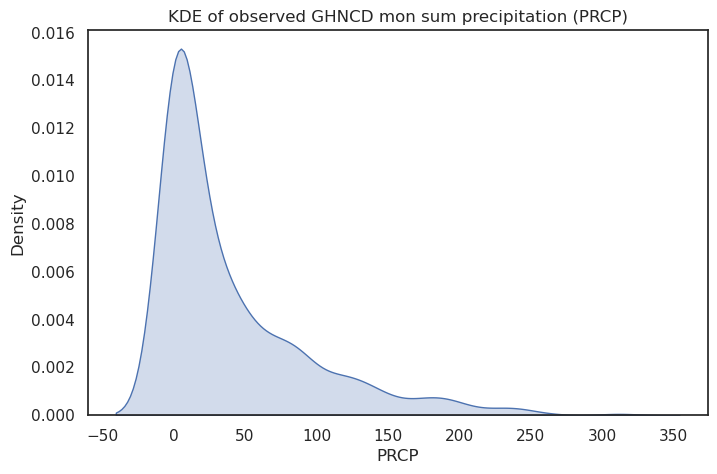

In [29]:
universalKDE('PRCP','observed GHNCD mon sum precipitation', mondf['PRCP'])

In [31]:
gnll2 = xr.open_dataset('~/signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_precip.nc')

In [33]:
gnll2['precip'].min()

<xarray.DataArray 'precip' ()> Size: 4B
array(-0.29795673, dtype=float32)

In [34]:
mondf['PRCP'].min()

0.0

In [35]:
import dataretrieval.nwis as nwis

In [67]:
# Input file information
time_var = 'datetime'  # Time variable name in source file for time series data
var_interest = 'discharge_cfs'
site = '11446500' #Site Number: American river at Fair Oaks
parameter_code = '00060' # Discharge (cfs)
start_date = "1904-10-01" # Beginning of record
end_date = "2025-06-01"

sig_start = '1940-01-01'
sig_end = "2025-06-01"

# Naming and formatting
data_type = "Streamflow" # Variable name in time series
data_unit = "cfs" # Variable unit in time series

In [68]:
#Download data 
df = nwis.get_record(sites = site, service = 'dv', start = start_date, end= end_date, parameterCd = parameter_code)
df[var_interest] = df[parameter_code+'_Mean']

# Ensure df index is also timezone-naive
df.index = df.index.tz_localize(None)

# Clip to the SAME date range as signal (inclusive)
df = df.loc[sig_start:sig_end]

# Resample to annual frequency and take the maximum daily
annual_max = df[var_interest].resample('M').max()
annual_mean = df[var_interest].resample('M').mean()
annual_sum = df[var_interest].resample('M').sum()
# Extract the year from each date
years = df.index.year

# Find the unique years
time = np.unique(years)

# Convert the series to a DataFrame
annual_max_df = annual_max.to_frame(name='annual_max_streamflow')

# Identify annual maxima
time_series = annual_max_df['annual_max_streamflow'].values

/tmp/ipykernel_3260/2522073099.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  annual_max = df[var_interest].resample('M').max()
/tmp/ipykernel_3260/2522073099.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  annual_mean = df[var_interest].resample('M').mean()
/tmp/ipykernel_3260/2522073099.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  annual_sum = df[var_interest].resample('M').sum()


In [69]:
annual_max.max()

132000.0

In [70]:
mon_max = annual_max_df.reset_index()

In [71]:
mon_max.columns=['time', 'cfs']

In [72]:
mon_max

,time,cfs
0,1940-01-31,24300.0
1,1940-02-29,57500.0
2,1940-03-31,69600.0
3,1940-04-30,29800.0
4,1940-05-31,11300.0
...,...,...
1021,2025-02-28,7730.0
1022,2025-03-31,6400.0
1023,2025-04-30,7480.0
1024,2025-05-31,4090.0


In [74]:
mon_max['time'] = pd.to_datetime(mon_max['time'], errors="coerce")

In [77]:
mon_max.to_csv('~/signal-extraction/vae_input_data/AR_cfs.csv', index=False)

In [81]:
annual_sum

datetime
1940-01-31    241740.0
1940-02-29    308840.0
1940-03-31    427050.0
1940-04-30    313410.0
1940-05-31    249230.0
                ...   
2025-02-28    145480.0
2025-03-31    100710.0
2025-04-30    158100.0
2025-05-31    111200.0
2025-06-30      2500.0
Freq: ME, Name: discharge_cfs, Length: 1026, dtype: float64

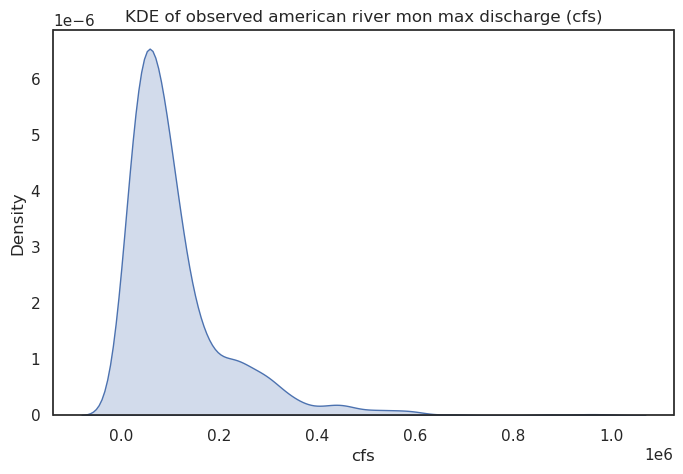

In [82]:
universalKDE('cfs','observed american river mon max discharge', annual_sum)

In [45]:
dfdrop = df.drop(columns = ['site_no','00060_Mean','00060_Mean_cd'])

In [46]:
dfdrop[

,discharge_cfs
datetime,
1940-01-01,1060.0
1940-01-02,6820.0
1940-01-03,13400.0
1940-01-04,6900.0
1940-01-05,5720.0
...,...
2024-09-27,1750.0
2024-09-28,1740.0
2024-09-29,1750.0


In [49]:
annual_max_df

,annual_max_streamflow
datetime,
1940-01-31,24300.0
1940-02-29,57500.0
1940-03-31,69600.0
1940-04-30,29800.0
1940-05-31,11300.0
...,...
2024-06-30,4680.0
2024-07-31,5220.0
2024-08-31,4460.0


In [47]:
dfdrop.reset_index()

,datetime,discharge_cfs
0,1940-01-01,1060.0
1,1940-01-02,6820.0
2,1940-01-03,13400.0
3,1940-01-04,6900.0
4,1940-01-05,5720.0
...,...,...
30951,2024-09-27,1750.0
30952,2024-09-28,1740.0
30953,2024-09-29,1750.0
30954,2024-09-30,1760.0


In [2]:
import xarray as xr
import numpy as np
from scipy.stats import linregress

# ----------------------------
# USER INPUTS
# ----------------------------
latent_csv = "~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv"          # must contain columns: time, latent
netcdf_file = "~/signal-extraction/vae_input_data/tp_mon-sum.nc"                  # 3D variable: time, lat, lon
netcdf_var  = "tp"                       # or precip, etc.

# ----------------------------
# LOAD LATENT INDEX
# ----------------------------
import pandas as pd

latent_df = pd.read_csv(latent_csv)
latent_df["time"] = pd.to_datetime(latent_df["time"])

# Ensure sorted
latent_df = latent_df.sort_values("time")

# convert to xarray for alignment
latent_xr = xr.DataArray(
    latent_df["latent"].values,
    coords={"time": latent_df["time"].values},
    dims=["time"]
)

# ----------------------------
# LOAD NETCDF FIELD
# ----------------------------
ds = xr.open_dataset(netcdf_file)
field = ds[netcdf_var]

# Ensure time alignment
field = field.sel(valid_time=slice(latent_df["time"].min(), latent_df["time"].max()))

# Reindex to match exactly (optional but safer)
field = field.reindex(time=latent_df["time"], method="nearest")

# ----------------------------
# SET UP OUTPUT ARRAYS
# ----------------------------
lat = field["lat"] if "lat" in field.coords else field["latitude"]
lon = field["lon"] if "lon" in field.coords else field["longitude"]

slopes   = np.zeros((len(lat), len(lon)))
ints     = np.zeros((len(lat), len(lon)))
pvals    = np.zeros((len(lat), len(lon)))
rvals    = np.zeros((len(lat), len(lon)))

# ----------------------------
# LOOP OVER GRID CELLS
# ----------------------------
for i in range(len(lat)):
    for j in range(len(lon)):
        y = field[:, i, j].values
        x = latent_xr.values

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 3:    # too few valid points
            slopes[i, j] = np.nan
            ints[i, j]   = np.nan
            pvals[i, j]  = np.nan
            rvals[i, j]  = np.nan
            continue

        lr = linregress(x[mask], y[mask])

        ints[i, j]   = lr.intercept
        slopes[i, j] = lr.slope
        pvals[i, j]  = lr.pvalue
        rvals[i, j]  = lr.rvalue

# ----------------------------
# BUILD XARRAY OUTPUTS
# ----------------------------
reg_ds = xr.Dataset(
    {
        "slope":     (("lat", "lon"), slopes),
        "intercept": (("lat", "lon"), ints),
        "pvalue":    (("lat", "lon"), pvals),
        "rvalue":    (("lat", "lon"), rvals),
    },
    coords={"lat": lat, "lon": lon}
)

# ----------------------------
# SAVE OR RETURN
# ----------------------------
reg_ds.to_netcdf("latent_regression_results.nc")
print("Saved regression results to latent_regression_results.nc")



Saved regression results to latent_regression_results.nc


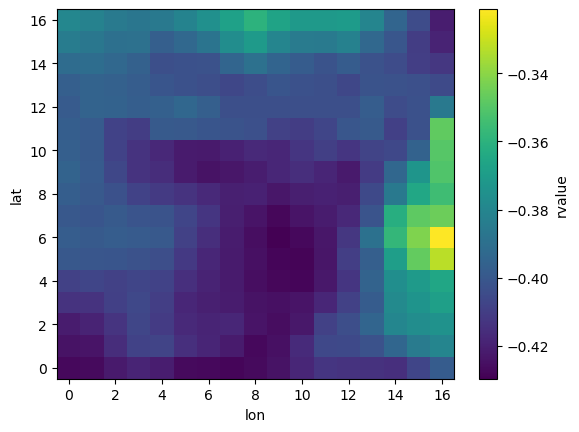

In [7]:
reg_ds["rvalue"].plot(x="lon", y="lat")

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def timeplot(time, series1, series2,label1="Series 1", label2="Series 2", title="Comparison of Time Series"):
    
    # Build DataFrame and drop NaNs
    df = pd.DataFrame({
        "time": time,
        "s1": series1,
        "s2": series2
    }).dropna()

    # Convert explicitly to float (prevents ValueError)
    df["s1"] = pd.to_numeric(df["s1"], errors="coerce")
    df["s2"] = pd.to_numeric(df["s2"], errors="coerce")
    df = df.dropna()

    if len(df) < 2:
        raise ValueError("Not enough overlapping data points to compute R².")

    s1 = df["s1"].values.astype(float)
    s2 = df["s2"].values.astype(float)

    # Compute R²
    r2 = r2_score(s1, s2)

    # Standardize for plotting
    s1_std = (s1 - np.mean(s1)) / np.std(s1)
    s2_std = (s2 - np.mean(s2)) / np.std(s2)

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(df["time"], s1_std, label=f"{label1} (R²={r2:.2f})", linewidth=1.25)
    plt.plot(df["time"], s2_std, label=label2, linewidth=1.25)

    plt.title(title, fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Standardized Index")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return r2


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def timeplot_df(
    df1, timecol1, seriescol1,
    df2, timecol2, seriescol2,
    label1="Series 1", label2="Series 2",
    title="Comparison of Time Series"
):
    """
    Plot two time series from two separate DataFrames, aligned by time.
    Computes and displays R².
    """

    # --- Standardize time and numeric types ---
    df1 = df1.copy()
    df2 = df2.copy()

    df1[timecol1] = pd.to_datetime(df1[timecol1], errors="coerce")
    df2[timecol2] = pd.to_datetime(df2[timecol2], errors="coerce")

    df1[seriescol1] = pd.to_numeric(df1[seriescol1], errors="coerce")
    df2[seriescol2] = pd.to_numeric(df2[seriescol2], errors="coerce")

    # --- Align by time using merge_asof or inner join ---
    # Convert to same monthly timestamp if needed
    df1["time_norm"] = df1[timecol1].dt.to_period("M").dt.to_timestamp()
    df2["time_norm"] = df2[timecol2].dt.to_period("M").dt.to_timestamp()

    merged = df1[["time_norm", seriescol1]].merge(
        df2[["time_norm", seriescol2]],
        on="time_norm",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 2:
        raise ValueError("Not enough overlapping aligned timestamps to compute R².")

    # Extract aligned series
    time = merged["time_norm"]
    s1 = merged[seriescol1].astype(float).values
    s2 = merged[seriescol2].astype(float).values

    # Compute R²
    r2 = r2_score(s1, s2)

    # Standardize for visualization
    s1_std = (s1 - np.mean(s1)) / np.std(s1)
    s2_std = (s2 - np.mean(s2)) / np.std(s2)

    # --- Plot ---
    plt.figure(figsize=(14, 4))
    plt.plot(time, s1_std, label=f"{label1} (R²={r2:.2f})", linewidth=1.25)
    plt.plot(time, s2_std, label=label2, linewidth=1.25)

    plt.title(title, fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Standardized Value")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return r2


In [1]:
latent = pd.read_csv("~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv")
latent = latent.drop(columns = ['alpha','beta','lambda'])
latent["time"] = pd.to_datetime(latent["time"]).dt.to_period("M").dt.to_timestamp()
latent['3mol'] = latent["latent"].rolling(window=3, center=True).mean()


precip = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")
precip['time'] = pd.to_datetime(precip["time"]).dt.to_period("M").dt.to_timestamp()
precip['3mop'] = precip['PRCP'].rolling(window=3, center = True).mean()

NameError: name 'pd' is not defined

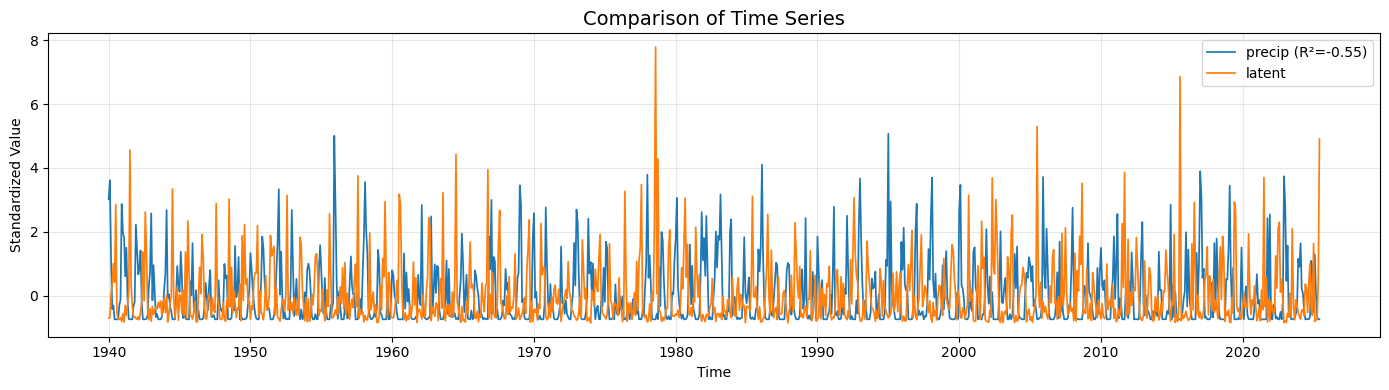

-0.5456019057680805

In [17]:
timeplot_df(precip, 'time', 'PRCP', latent, 'time', 'latent', 'precip', 'latent')

In [20]:
from scipy.stats import pearsonr
s1 = latent['latent']
s2 = precip['PRCP']
    

r, p = pearsonr(s1, s2)


In [21]:
r

np.float64(-0.3956393673021263)

In [33]:
p

np.float64(8.803483265085861e-40)

In [34]:
r*r

np.float64(0.1565305089592268)

In [23]:
import statsmodels.api as sm
import pandas as pd

y= precip['PRCP']
X = latent['latent']

model = sm.OLS(y, X)
results = model.fit()

In [24]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   PRCP   R-squared (uncentered):                   0.021
Model:                            OLS   Adj. R-squared (uncentered):              0.020
Method:                 Least Squares   F-statistic:                              22.30
Date:                Thu, 11 Dec 2025   Prob (F-statistic):                    2.66e-06
Time:                        04:16:59   Log-Likelihood:                         -5761.7
No. Observations:                1026   AIC:                                  1.153e+04
Df Residuals:                    1025   BIC:                                  1.153e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
latent        13.8225      2.927      4.722      0.000       8.078      19.567
==============================================================================
Omnibus:                      303.059   Durbin-Watson:                   0.813
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.240
Skew:                           1.598   Prob(JB):                    6.59e-157
Kurtosis:                       5.570   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
latent['3mol'] = latent["latent"].rolling(window=3, center=True).mean()

precip['3mop'] = precip['PRCP'].rolling(window=3, center = True).mean()

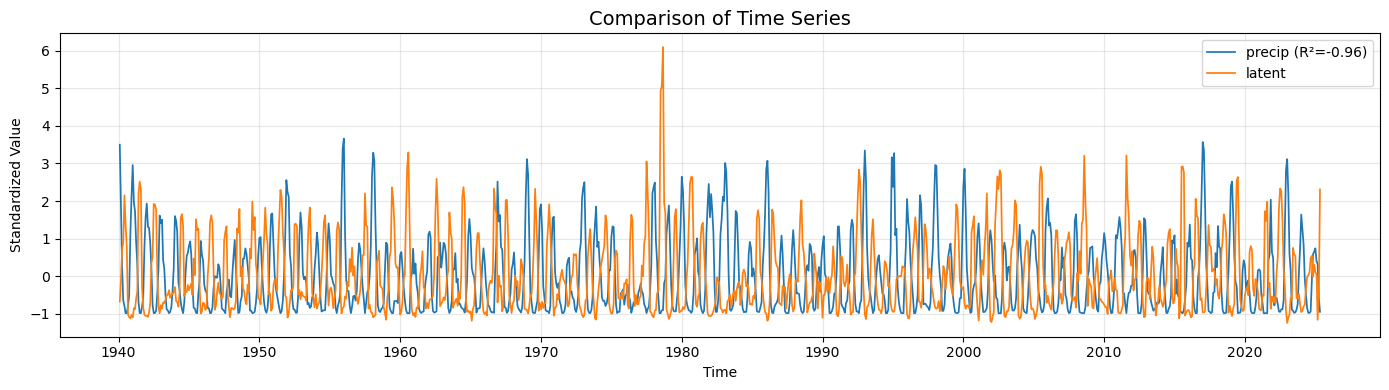

-0.9580466395938174

In [40]:
timeplot_df(precip, 'time', '3mop', latent, 'time', '3mol', 'precip', 'latent')

In [49]:
precip = precip.dropna()

In [48]:
latent = latent.dropna()

In [50]:
latent

,time,latent,3mol
1,1940-02-01,0.089934,0.218840
2,1940-03-01,0.483903,0.410084
3,1940-04-01,0.656417,0.713938
4,1940-05-01,1.001494,0.781192
5,1940-06-01,0.685667,1.227625
...,...,...,...
1020,2025-01-01,1.340797,0.498396
1021,2025-02-01,0.024639,0.473650
1022,2025-03-01,0.055516,0.044790
1023,2025-04-01,0.054215,0.269011


In [51]:
y3= precip['3mop']
X3 = latent['3mol']

model3 = sm.OLS(y3, X3)
results3 = model.fit()

In [52]:
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   PRCP   R-squared (uncentered):                   0.021
Model:                            OLS   Adj. R-squared (uncentered):              0.020
Method:                 Least Squares   F-statistic:                              22.30
Date:                Thu, 11 Dec 2025   Prob (F-statistic):                    2.66e-06
Time:                        04:33:12   Log-Likelihood:                         -5761.7
No. Observations:                1026   AIC:                                  1.153e+04
Df Residuals:                    1025   BIC:                                  1.153e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
latent        13.8225      2.927      4.722      0.000       8.078      19.567
==============================================================================
Omnibus:                      303.059   Durbin-Watson:                   0.813
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.240
Skew:                           1.598   Prob(JB):                    6.59e-157
Kurtosis:                       5.570   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def timeplot_multi(series_list, labels=None, title="Multi-Series Comparison", target_index=None):
    """
    Plot multiple aligned time series from (df, seriescol) pairs.
    Compute Pearson correlation r between a target series and all others.

    series_list: list of (df, column_name)
    labels:      list of labels (optional)
    target_index: index of the reference series for r calculations
    """

    n = len(series_list)
    if labels is None:
        labels = [f"Series {i+1}" for i in range(n)]
    if len(labels) != n:
        raise ValueError("Length of labels must match length of series_list")

    aligned = None

    # -----------------------
    # STEP 1: Load and align time series
    # -----------------------
    for i, (df, scol) in enumerate(series_list):

        df = df.copy()
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df[scol] = pd.to_numeric(df[scol], errors="coerce")

        # Convert timestamps to month-start
        df["time_norm"] = df["time"].dt.to_period("M").dt.to_timestamp()

        df_i = df[["time_norm", scol]].rename(columns={scol: labels[i]})

        aligned = df_i if aligned is None else aligned.merge(df_i, on="time_norm", how="inner")

    aligned = aligned.dropna()

    if len(aligned) < 2:
        raise ValueError("Not enough overlapping timestamps across all series.")

    # -----------------------
    # STEP 2: Standardize for plotting
    # -----------------------
    time = aligned["time_norm"]
    standardized = {}

    for label in labels:
        x = aligned[label].astype(float).values
        standardized[label] = (x - x.mean()) / x.std()

    # -----------------------
    # STEP 3: Compute Pearson r if requested
    # -----------------------
    r_values = None

    if target_index is not None:
        if not (0 <= target_index < n):
            raise ValueError(f"target_index must be between 0 and {n-1}")

        target_label = labels[target_index]
        y = aligned[target_label].astype(float).values

        r_values = {}

        for i, label in enumerate(labels):
            if i == target_index:
                continue
            x = aligned[label].astype(float).values
            r, _ = pearsonr(y, x)
            r_values[label] = r

    # -----------------------
    # STEP 4: Plot all standardized series
    # -----------------------
    plt.figure(figsize=(14, 5))

    for i, label in enumerate(labels):
        if r_values and i != target_index:
            r_txt = f" (r={r_values[label]:.2f})"
        else:
            r_txt = ""

        plt.plot(time, standardized[label], label=label + r_txt, linewidth=1.2)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Standardized Value")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return aligned, r_values


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from npeet_plus.estimators import mi   # <-- MI estimator (kNN Kraskov)

def timeplot_multi_MI(series_list, labels=None, title="Multi-Series Comparison (MI)", target_index=None, base=2):
    """
    Plot multiple aligned time series from (df, seriescol) pairs.
    Compute Mutual Information (MI) between a target series and all others.

    series_list: list of (df, column_name)
    labels:      list of labels (optional)
    target_index: index of the reference series for MI calculations
    base: logarithm base for MI (default=2 for bits)
    """

    n = len(series_list)
    if labels is None:
        labels = [f"Series {i+1}" for i in range(n)]
    if len(labels) != n:
        raise ValueError("Length of labels must match length of series_list")

    aligned = None

    # ----------------------------------------------------------------------
    # STEP 1: Load and align time series
    # ----------------------------------------------------------------------
    for i, (df, scol) in enumerate(series_list):

        df = df.copy()
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df[scol] = pd.to_numeric(df[scol], errors="coerce")

        # Normalize timestamps to month-start
        df["time_norm"] = df["time"].dt.to_period("M").dt.to_timestamp()

        df_i = df[["time_norm", scol]].rename(columns={scol: labels[i]})

        aligned = df_i if aligned is None else aligned.merge(df_i, on="time_norm", how="inner")

    aligned = aligned.dropna()

    if len(aligned) < 2:
        raise ValueError("Not enough overlapping timestamps across all series.")

    # ----------------------------------------------------------------------
    # STEP 2: Standardize for plotting
    # ----------------------------------------------------------------------
    time = aligned["time_norm"]
    standardized = {}

    for label in labels:
        x = aligned[label].astype(float).values
        standardized[label] = (x - x.mean()) / x.std()

    # ----------------------------------------------------------------------
    # STEP 3: Compute Mutual Information (MI)
    # ----------------------------------------------------------------------
    MI_values = None

    if target_index is not None:
        if not (0 <= target_index < n):
            raise ValueError(f"target_index must be between 0 and {n-1}")

        target_label = labels[target_index]
        y = aligned[target_label].astype(float).values.reshape(-1, 1)

        MI_values = {}

        for i, label in enumerate(labels):
            if i == target_index:
                continue

            x = aligned[label].astype(float).values.reshape(-1, 1)
            MI_xy = mi(x, y, base=base)  # <-- kNN mutual information
            MI_values[label] = MI_xy

    # ----------------------------------------------------------------------
    # STEP 4: Plot all standardized series
    # ----------------------------------------------------------------------
    plt.figure(figsize=(14, 5))

    for i, label in enumerate(labels):
        if MI_values and i != target_index:
            mi_txt = f" (MI={MI_values[label]:.2f} bits)"
        else:
            mi_txt = ""

        plt.plot(time, standardized[label], label=label + mi_txt, linewidth=1.2)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Standardized Value")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return aligned, MI_values

In [2]:
nino = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')
pdo = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
pna = pd.read_csv('~/signal-extraction/vae_input_data/ncep_pna_index.csv')

mimoae = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

mimoae['time'] = pd.to_datetime(mimoae["time"]).dt.to_period("M").dt.to_timestamp()

mimoae['ae3'] = mimoae['latent'].rolling(window=3, center = True).mean()

nino = nino.rename(columns={'DATE':'time','INDEX' : 'nino'})

pdo = pdo.rename(columns={'Date':'time','value' : 'pdo'})

pna = pna.rename(columns={'Date':'time','value' : 'pna'})

nino['nino3'] = nino['nino'].rolling(window=3, center = True).mean()
pdo['pdo3'] = pdo['pdo'].rolling(window=3, center = True).mean()
pna['pna3'] = pna['pna'].rolling(window=3, center = True).mean()

latent = pd.read_csv("~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv")

precip = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")

latent = latent.drop(columns = ['alpha','beta','lambda'])

latent["time"] = pd.to_datetime(latent["time"]).dt.to_period("M").dt.to_timestamp()

latent['3mol'] = latent["z"].rolling(window=3, center=True).mean()

precip['3mop'] = precip['PRCP'].rolling(window=3, center = True).mean()

NameError: name 'pd' is not defined

In [22]:
import xarray as xr
import pandas as pd
import numpy as np

# Load dataset
era5 = xr.open_dataset('~/signal-extraction/vae_input_data/tp_mon-sum.nc')

# Extract variable
tp = era5['tp']   # dims should be (time, lat, lon)

# Simple domain average
tp_mean = tp.mean(dim=("latitude", "longitude"))

# Convert to pandas DataFrame usable by timeplot_multi_MI
df_tp = tp_mean.to_dataframe().reset_index()
df_tp = df_tp.rename(columns={"valid_time": "time"})  # rename the variable for clarity
df_tp["time"] = pd.to_datetime(df_tp["time"]).dt.to_period("M").dt.to_timestamp()

df_tp['3motp'] = df_tp['tp'].rolling(window=3, center = True).mean()

df_tp.head()

,time,tp,3motp
0,1940-01-01,0.180173,NaN
1,1940-02-01,0.250356,0.188811
2,1940-03-01,0.135904,0.137371
3,1940-04-01,0.025854,0.058756
4,1940-05-01,0.014510,0.017565


In [23]:
plotlist =[
    (df_tp, "3motp"),
    (latent, "3mol"), 
    (nino, 'nino3'),
    (pdo, 'pdo3'),
    (pna, 'pna3'),
    (mimoae, 'ae3')
    ]

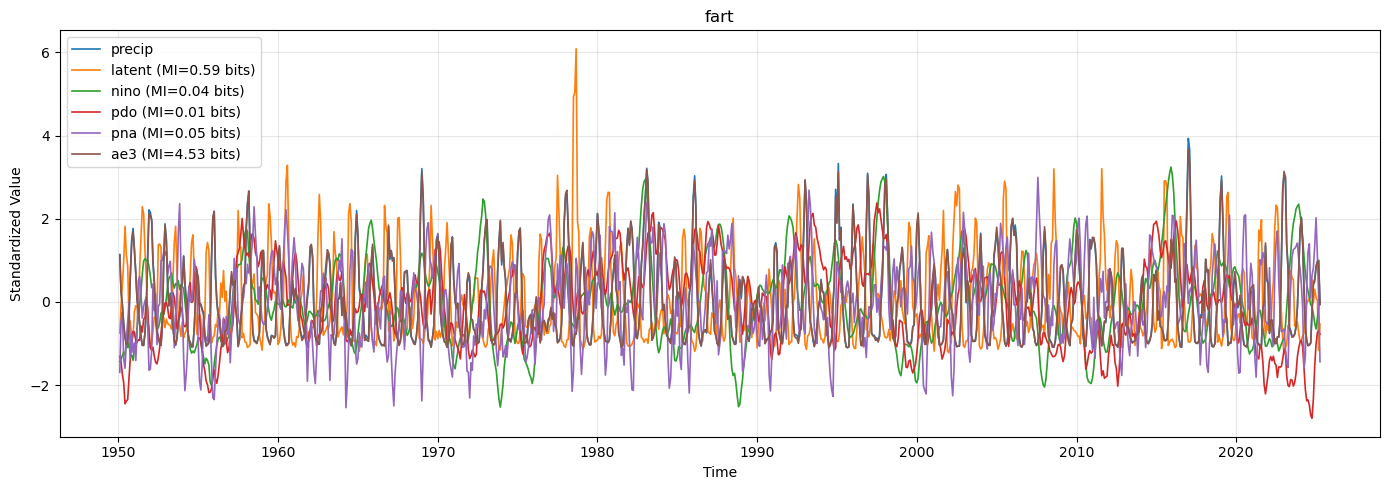

(     time_norm    precip    latent      nino       pdo       pna       ae3
 1   1950-02-01  0.110397  0.192926 -1.206667 -1.890000 -1.046667 -0.657430
 2   1950-03-01  0.068103  0.417151 -1.160000 -2.016667 -0.263333 -0.753783
 3   1950-04-01  0.051714  0.602933 -1.093333 -2.356667 -0.100000 -0.792665
 4   1950-05-01  0.029871  0.808578 -1.023333 -2.566667 -0.836667 -0.842696
 5   1950-06-01  0.013578  1.110956 -1.080000 -3.120000 -0.983333 -0.878034
 ..         ...       ...       ...       ...       ...       ...       ...
 899 2024-12-01  0.081431  0.568184 -0.463333 -2.146667  0.936667 -0.728905
 900 2025-01-01  0.097030  0.498396 -0.576667 -1.570000  1.386667 -0.690955
 901 2025-02-01  0.102564  0.473650 -0.366667 -1.266667  0.786667 -0.676785
 902 2025-03-01  0.103684  0.044790 -0.140000 -1.223333  0.146667 -0.672815
 903 2025-04-01  0.052233  0.269011 -0.036667 -1.310000 -0.880000 -0.789704
 
 [903 rows x 7 columns],
 {'latent': np.float64(0.5921062384414372),
  'nino': np.floa

In [24]:
timeplot_multi(plotlist, labels = ['precip','latent','nino','pdo','pna', 'ae3'], title = 'fart', target_index=0)

In [115]:
mimoae= mimoae.dropna()

In [116]:
y4= precip['3mop']
X4 = mimoae['ae3']

model4 = sm.OLS(y4, X4)
results4 = model.fit()

In [117]:
results4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   PRCP   R-squared (uncentered):                   0.021
Model:                            OLS   Adj. R-squared (uncentered):              0.020
Method:                 Least Squares   F-statistic:                              22.30
Date:                Thu, 11 Dec 2025   Prob (F-statistic):                    2.66e-06
Time:                        05:11:11   Log-Likelihood:                         -5761.7
No. Observations:                1026   AIC:                                  1.153e+04
Df Residuals:                    1025   BIC:                                  1.153e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
latent        13.8225      2.927      4.722      0.000       8.078      19.567
==============================================================================
Omnibus:                      303.059   Durbin-Watson:                   0.813
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.240
Skew:                           1.598   Prob(JB):                    6.59e-157
Kurtosis:                       5.570   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
import pandas as pd
import statsmodels.api as sm

def lagged_regression(df, ycol, xcol, max_lag=3):
    """
    df    : DataFrame with datetime index
    ycol  : column name of dependent variable (Y_t)
    xcol  : column name of predictor variable (X_t)
    max_lag : number of lag months to include (default = 3)
    
    Returns:
        results : statsmodels regression results
        X       : design matrix used for regression
    """

    df = df.copy()

    # Create lagged predictors: X(t-1), X(t-2), X(t-3)
    for lag in range(1, max_lag + 1):
        df[f"{xcol}_lag{lag}"] = df[xcol].shift(lag)

    # Drop rows that contain NaN due to lagging
    df = df.dropna()

    # Build regression matrix
    X = df[[f"{xcol}_lag{lag}" for lag in range(1, max_lag + 1)]]

    # Add intercept
    X = sm.add_constant(X)

    # Dependent variable
    y = df[ycol]

    # Fit OLS regression
    model = sm.OLS(y, X)
    results = model.fit()

    return results, X


In [38]:
results, x = lagged_regression(merged, 'latent', 'PRCP')

In [39]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 latent   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     35.65
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           6.54e-22
Time:                        11:11:42   Log-Likelihood:                -769.08
No. Observations:                1023   AIC:                             1546.
Df Residuals:                    1019   BIC:                             1566.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5969      0.023     26.358      0.000       0.552       0.641
PRCP_lag1     -0.0027      0.000     -8.177      0.000      -0.003      -0.002
PRCP_lag2     -0.0008      0.000     -2.252      0.025      -0.002      -0.000
PRCP_lag3      0.0001      0.000      0.377      0.706      -0.001       0.001
==============================================================================
Omnibus:                      563.935   Durbin-Watson:                   1.828
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4683.311
Skew:                           2.427   Prob(JB):                         0.00
Kurtosis:                      12.290   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
import statsmodels.api as sm
import pandas as pd

def no_lag_regression(df, ycol, xcol):
    """
    df   : DataFrame with datetime index
    ycol : dependent variable (e.g., 'latent')
    xcol : predictor variable (e.g., 'PRCP')
    """
    
    df = df.copy().dropna(subset=[ycol, xcol])

    # Design matrix: only contemporaneous PRCP
    X = sm.add_constant(df[xcol])
    y = df[ycol]

    model = sm.OLS(y, X)
    results = model.fit()

    return results

In [41]:
results2 = no_lag_regression(merged, 'latent', 'PRCP')

In [42]:
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 latent   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     190.0
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           8.80e-40
Time:                        11:14:25   Log-Likelihood:                -734.19
No. Observations:                1026   AIC:                             1472.
Df Residuals:                    1024   BIC:                             1482.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6193      0.019     32.160      0.000       0.582       0.657
PRCP          -0.0040      0.000    -13.785      0.000      -0.005      -0.003
==============================================================================
Omnibus:                      595.554   Durbin-Watson:                   1.859
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5688.246
Skew:                           2.538   Prob(JB):                         0.00
Kurtosis:                      13.358   Cond. No.                         83.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [3]:
import os
os.getcwd()

'/home/jovyan/signal-extraction/workbench'